# Pore Pipeline — Colab Runner

End-to-end facial pore analysis from a single RGB smartphone selfie.

**This is a skincare analysis tool, not a medical device.** No disease diagnosis is attempted or supported.

## Runtime

Before running: **Runtime → Change runtime type → T4 GPU** (required for SAM 2, DINOv2, Depth Anything V2).

On CPU-only Colab the pipeline will still run but foundation-model stages will be slow (~1-2 min per face) or skipped.

## 1. Install dependencies

Colab already has numpy/scipy/opencv/matplotlib/torch. We install the rest.

In [16]:
%%bash
pip install -q --upgrade \
    "mediapipe>=0.10.14" \
    "onnxruntime-gpu" \
    "transformers>=4.45" \
    "accelerate>=0.33" \
    "scikit-image>=0.22" \
    huggingface_hub tqdm Pillow

## 2. Copy the pore_pipeline package

Upload the `pore_pipeline/` directory (or unzip it here). Expected layout:

```
/content/pore_pipeline/
    __init__.py
    config.py
    ... (all stage modules)
```

In [17]:
import sys, os
sys.path.insert(0, '/content')

# Sanity check
import pore_pipeline as pp
print('pore_pipeline version:', pp.PIPELINE_VERSION)
print('Public exports:', len(pp.__all__))
print('Zones:', pp.ALL_ZONES)

pore_pipeline version: pore-pipeline-0.1.0
Public exports: 42
Zones: ['forehead', 'glabella', 'nose_dorsum', 'nose_tip', 'nose_ala_left', 'nose_ala_right', 'cheek_medial_left', 'cheek_medial_right', 'cheek_lateral_left', 'cheek_lateral_right', 'chin', 'perioral']


## 3. Upload a selfie

One unfiltered RGB smartphone selfie. Front-facing. No beauty filter.

Tips for best results:
- Face the camera head-on (yaw/pitch/roll each < 15°).
- Soft, even lighting (avoid harsh side light — creates false-positive pores in shadows).
- Hair pulled back from forehead if possible.
- Camera ~25-35 cm from face (too far = pores unresolvable; too close = lens distortion).
- No makeup ideally, or minimal; heavy makeup fills pores and under-counts them.

Saving 20260420_081533.jpg to 20260420_081533.jpg
Uploaded: 20260420_081533.jpg


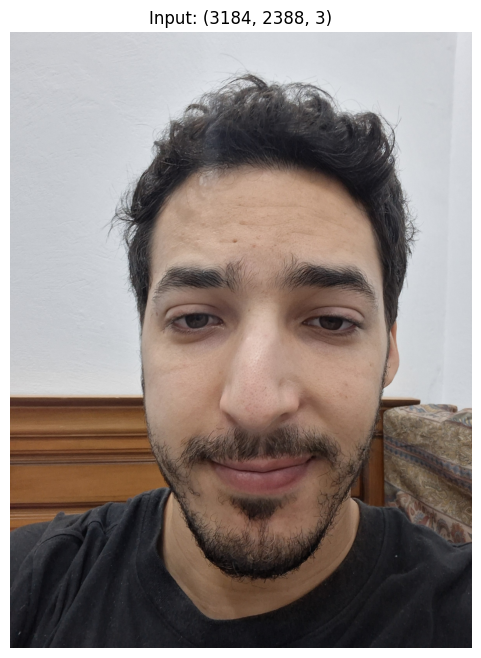

In [18]:
from google.colab import files
uploaded = files.upload()   # pick one .jpg / .png
image_path = list(uploaded.keys())[0]
print(f'Uploaded: {image_path}')

import cv2
import matplotlib.pyplot as plt
bgr = cv2.imread(image_path)
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
plt.title(f'Input: {bgr.shape}')
plt.axis('off')
plt.show()

## 4. Load models

First run downloads:
- MediaPipe face_landmarker.task (~4 MB)
- BiSeNet face parser ONNX (~50 MB)
- DINOv2 small (~90 MB)
- SAM 2 hiera base (~160 MB)
- Depth Anything V2 small (~100 MB)

Subsequent runs use the cache.

In [19]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

from pore_pipeline import (
    PipelineModels,
    FaceLandmarkDetector, BiSeNetONNXParser,
    DinoV2Encoder, Sam2Prompter, DepthAnythingV2Encoder,
)

Device: cpu


In [20]:
print('Loading MediaPipe FaceLandmarker...')
face_det = FaceLandmarkDetector()
print('  OK')

print('Loading BiSeNet face parser...')
try:
    parser = BiSeNetONNXParser()
    print('  OK')
except Exception as e:
    print(f'  FAILED: {e} — continuing with landmarks-only')
    parser = None

Loading MediaPipe FaceLandmarker...
  OK
Loading BiSeNet face parser...
  OK


In [21]:
print('Loading DINOv2 small...')
try:
    dino = DinoV2Encoder(device=device)
    # Force load now to catch issues early.
    dino._ensure_loaded()
    print('  OK')
except Exception as e:
    print(f'  FAILED: {e} — continuing without Signal A')
    dino = None

print('Loading SAM 2 hiera base...')
try:
    sam = Sam2Prompter(device=device)
    sam._ensure_loaded()
    print('  OK')
except Exception as e:
    print(f'  FAILED: {e} — continuing without Signal B')
    sam = None

print('Loading Depth Anything V2 small...')
try:
    depth = DepthAnythingV2Encoder(device=device)
    depth._ensure_loaded()
    print('  OK')
except Exception as e:
    print(f'  FAILED: {e} — continuing without Signal C')
    depth = None

Loading DINOv2 small...
  FAILED: DINOv2 failed to load (facebook/dinov2-small): cannot import name '_Ink' from 'PIL._typing' (/usr/local/lib/python3.12/dist-packages/PIL/_typing.py) — continuing without Signal A
Loading SAM 2 hiera base...
  FAILED: SAM 2 failed to load (facebook/sam2-hiera-base-plus): cannot import name '_Ink' from 'PIL._typing' (/usr/local/lib/python3.12/dist-packages/PIL/_typing.py) — continuing without Signal B
Loading Depth Anything V2 small...
  FAILED: Depth Anything V2 failed to load (depth-anything/Depth-Anything-V2-Small-hf): cannot import name '_Ink' from 'PIL._typing' (/usr/local/lib/python3.12/dist-packages/PIL/_typing.py) — continuing without Signal C


In [22]:
models = PipelineModels(
    face_detector=face_det,
    face_parser=parser,
    dino=dino,
    sam=sam,
    depth=depth,
    flament_calib=None,   # heuristic mode until anchor images provided
    ibsa_calib=None,
)
print('Models ready.')

Models ready.


## 5. Run the pipeline

In [23]:
from pore_pipeline import run_pipeline

result = run_pipeline(
    image_path=image_path,
    models=models,
    output_json_path='/content/result.json',
    debug_keep_intermediates=True,
    max_candidates_to_sam=1500,   # SAM2 prompt budget — lower on low-VRAM
)

print(f'\n=== Results ===')
print(f'Quality gate passed: {result.quality.passed}')
if result.quality.reasons:
    print(f'Reasons: {result.quality.reasons}')
if result.quality.warnings:
    print(f'Warnings: {result.quality.warnings}')

if result.whole_face:
    print(f'\nFitzpatrick: {result.fitzpatrick}')
    print(f'Detected pores: {len(result.records)} (rejected: {len(result.rejected)})')
    print(f'Composite pore score: {result.whole_face.composite_score_0_100:.1f}/100')
    print(f'  plausibility: {result.whole_face.composite_score_plausibility_interval[0]:.1f}'
          f' - {result.whole_face.composite_score_plausibility_interval[1]:.1f}')
    print(f'IBSA pore grade: {result.whole_face.ibsa_pore_grade_1_5}/5')
    print(f'Dominant zone: {result.whole_face.dominant_zone_id}')
    print(f'Asymmetry index: {result.whole_face.asymmetry_index:.1f}')

print(f'\nTimings (ms):')
for stage, ms in result.timings_ms.items():
    print(f'  {stage:22s} {ms:8.1f}')
print(f'  {"TOTAL":22s} {sum(result.timings_ms.values()):8.1f}')


=== Results ===
Quality gate passed: True

Fitzpatrick: V
Detected pores: 40491 (rejected: 0)
Composite pore score: 78.3/100
  plausibility: 66.6 - 90.0
IBSA pore grade: 5/5
Dominant zone: forehead
Asymmetry index: 0.0

Timings (ms):
  load_ms                   162.8
  face_ms                   101.5
  quality_ms                338.4
  skin_ms                   527.1
  illum_ms                 1571.6
  zones_ms                  198.4
  candidates_ms           15187.1
  suppression_ms            201.3
  metrology_ms             1698.6
  aggregate_ms               34.5
  whole_face_ms               0.1
  TOTAL                   20021.4


## 6. Per-zone diagnostics

In [24]:
print(f'{"Zone":22s} {"N":>4s} {"Dens/cm2":>9s} {"MeanØµm":>8s} '
      f'{"Vis":>5s} {"Flam":>5s} {"Cov":>5s} Plausible')
print('-' * 80)
for zid, agg in result.zone_aggs.items():
    p = '✓' if agg.density_plausible else '⚠'
    meas = '' if agg.measurable else ' [not measurable]'
    print(f'{zid:22s} {agg.count:>4d} {agg.density_per_cm2:>9.1f} '
          f'{agg.mean_diameter_mm*1000:>8.0f} {agg.visibility_mean:>5.1f} '
          f'{agg.flament_score:>5.2f} {agg.coverage_ratio*100:>4.0f}% {p}{meas}')

Zone                      N  Dens/cm2  MeanØµm   Vis  Flam   Cov Plausible
--------------------------------------------------------------------------------
forehead               40491     301.9      235  45.7  7.05   89% ⚠
glabella                  0       0.0        0   0.0  0.00   81% ✓
nose_dorsum               0       0.0        0   0.0  0.00   84% ✓
nose_tip                  0       0.0        0   0.0  0.00   79% ✓
nose_ala_left             0       0.0        0   0.0  0.00   77% ✓
nose_ala_right            0       0.0        0   0.0  0.00   76% ✓
cheek_medial_left         0       0.0        0   0.0  0.00  100% ✓
cheek_medial_right        0       0.0        0   0.0  0.00  100% ✓
cheek_lateral_left        0       0.0        0   0.0  0.00  100% ✓
cheek_lateral_right       0       0.0        0   0.0  0.00  100% ✓
chin                      0       0.0        0   0.0  0.00   89% ✓
perioral                  0       0.0        0   0.0  0.00    6% ✓ [not measurable]


## 7. Render dashboard

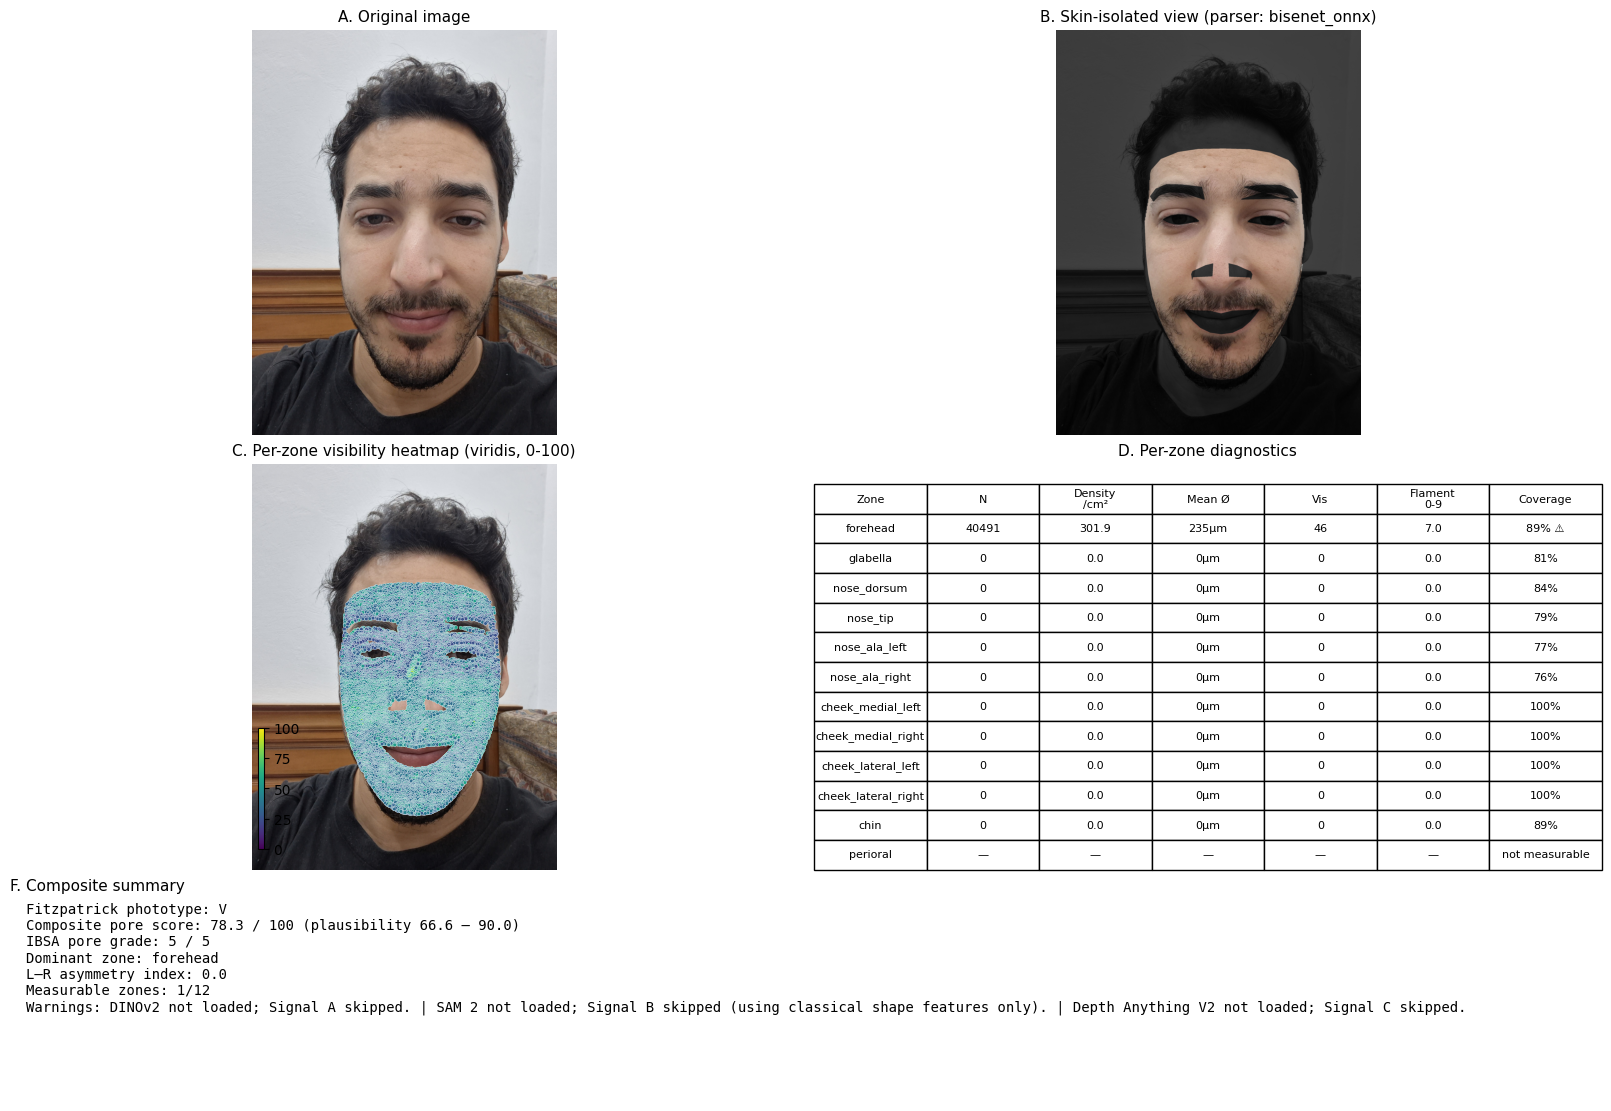

In [25]:
from pore_pipeline import render_dashboard

fig = render_dashboard(
    bgr=bgr,
    skin=result.debug['skin'],
    zones=result.debug['zones'],
    records=result.records,
    zone_aggs=result.zone_aggs,
    whole_face=result.whole_face,
    fitzpatrick=result.fitzpatrick,
    warnings=result.warnings,
)
fig.savefig('/content/dashboard.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Per-pore overlay (standalone)

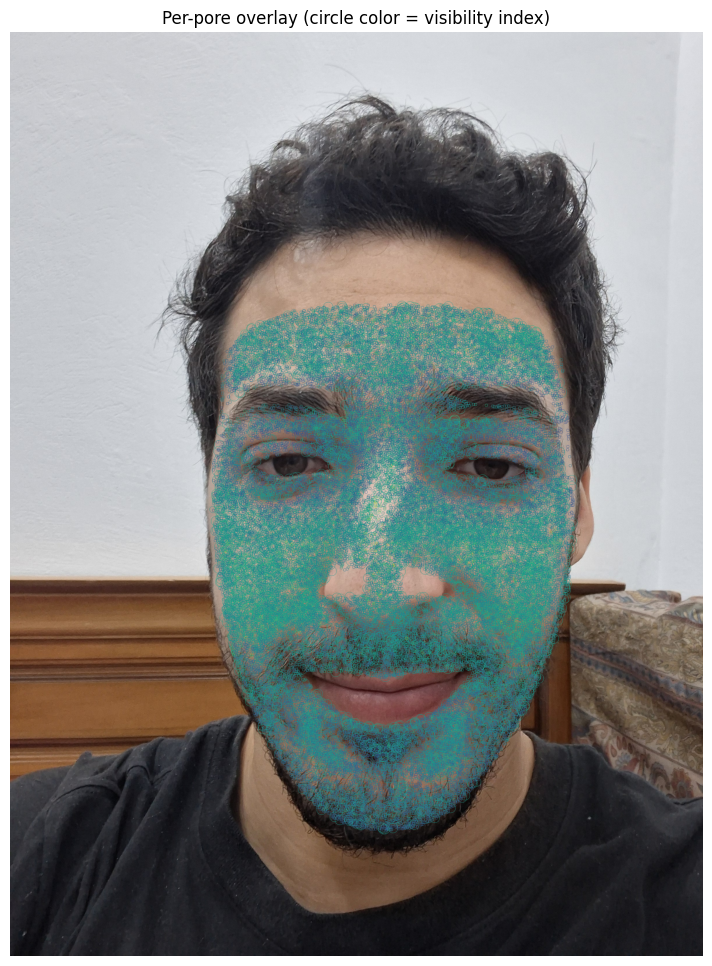

In [26]:
from pore_pipeline import render_per_pore_overlay

overlay_bgr = render_per_pore_overlay(bgr, result.records, alpha=0.8)
cv2.imwrite('/content/overlay.png', overlay_bgr)
plt.figure(figsize=(10, 12))
plt.imshow(cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB))
plt.title('Per-pore overlay (circle color = visibility index)')
plt.axis('off')
plt.show()

## 9. Inspect the JSON output

In [27]:
import json
with open('/content/result.json') as f:
    data = json.load(f)

# Top-level summary
print('Schema:', data['schema_version'])
print('Calibration basis:', data['calibration_basis_global'])
print('Limitations:', data['limitations'])
print('Warnings:', data['warnings'])

# Whole face
if data.get('whole_face'):
    print('\nWhole face:')
    for k, v in data['whole_face'].items():
        print(f'  {k}: {v}')

print('\nFull JSON saved to /content/result.json')

Schema: pore.v1.0
Calibration basis: heuristic_no_anchors
Limitations: ['fitzpatrick_V_VI_flament_extrapolated', 'dino_signal_unavailable', 'sam2_signal_unavailable_metrology_from_classical_fit', 'depth_signal_unavailable_scar_discrimination_degraded', 'flament_mapping_heuristic_no_anchors']
Warnings: ['DINOv2 not loaded; Signal A skipped.', 'SAM 2 not loaded; Signal B skipped (using classical shape features only).', 'Depth Anything V2 not loaded; Signal C skipped.']

Whole face:
  composite_score_0_100: 78.3
  composite_score_plausibility_interval: [66.55, 90.04]
  ibsa_pore_grade_1_5: 5
  dominant_zone_id: forehead
  asymmetry_index: 0.0
  all_zones_measurable: False
  measurable_zones: ['forehead']

Full JSON saved to /content/result.json


## 10. Test-retest (optional)

Take 3 selfies of the same person in the same session, upload them as `selfie_1.jpg`, `selfie_2.jpg`, `selfie_3.jpg` and run this cell. The coefficient of variation (CV) of the composite score should be ≤ 15%.

In [28]:
import numpy as np
scores = []
counts = []
paths = [p for p in ['selfie_1.jpg', 'selfie_2.jpg', 'selfie_3.jpg']
         if os.path.exists(f'/content/{p}')]
if len(paths) < 2:
    print('Upload selfie_1.jpg, selfie_2.jpg (and optionally selfie_3.jpg) to run this.')
else:
    for p in paths:
        r = run_pipeline(f'/content/{p}', models, max_candidates_to_sam=1500)
        if r.whole_face:
            scores.append(r.whole_face.composite_score_0_100)
            counts.append(len(r.records))
            print(f'{p}: score={r.whole_face.composite_score_0_100:.1f}, '
                  f'count={len(r.records)}, fitz={r.fitzpatrick}')
    if len(scores) >= 2:
        score_cv = float(np.std(scores) / np.mean(scores)) * 100
        count_cv = float(np.std(counts) / np.mean(counts)) * 100
        print(f'\nComposite score CV: {score_cv:.1f}% (target <= 15%)')
        print(f'Pore count CV:     {count_cv:.1f}% (target <= 15%)')

Upload selfie_1.jpg, selfie_2.jpg (and optionally selfie_3.jpg) to run this.
